# Introduction

Spatial transcriptomics captures gene expression while preserving tissue architecture, enabling the study of cellular organization and microenvironments. However, identifying coherent spatial domains - regions of similar expression patterns and spatial context — remains challenging.

Graph Neural Networks (GNNs) are great for this type of data because they can model both gene expression features and spatial neighborhood relationships. In this project, I implemented a mini Graph Autoencoder (GAE) from scratch in PyTorch to learn unsupervised spatial embeddings of tissue spots from a toy Visium H&E dataset provided by Squidpy.

The aim was to demonstrate how GNNs can capture spatially coherent patterns in gene expression and to compare these learned embeddings to traditional PCA-based clustering.

# Methods

## Data
**Dataset:**  
`sq.datasets.visium_hne_adata()` — a 10x Genomics Visium H&E mouse brain section (~2,700 spots, ~33k genes).

**Preprocessing steps:**
- Filtered low-count genes  
- Normalized total counts and log-transformed data  
- Selected 2,000 highly variable genes using *Seurat v3*  
- Scaled each gene to zero mean and unit variance  

---

## Graph construction
- Built a *k*-nearest neighbor (kNN) graph from spatial coordinates (`k = 8`) using Euclidean distance.  
- Edge weights were computed with a **Gaussian kernel** on spatial distances and symmetrized.  
- The adjacency matrix was normalized as:  

\[
\hat{A} = D^{-1/2}(A + I)D^{-1/2}
\]

---

## Model
Implemented a **Graph Autoencoder (GAE)** consisting of:

- Two **Graph Convolutional Layers (GCNs)**  
  - First layer: input → 64 hidden units  
  - Second layer: 64 → 16-dimensional latent embedding  
- ReLU activation and 0.2 dropout between layers  
- **Unsupervised objective:** adjacency reconstruction loss  
  - Encourages embeddings of connected nodes to be similar  
  - Includes random negative samples to separate unconnected nodes  

---

## Training
- **Optimizer:** Adam (`lr = 1e-3`, `weight_decay = 1e-4`)  
- **Epochs:** 200  
- **Loss:** sum of positive-edge and negative-edge reconstruction terms  

---

## Clustering and visualization
- Performed **KMeans clustering** on the learned embeddings (`k = 6`).  
- Compared results to **PCA (16D) + KMeans** baseline.  
- Visualized clusters over tissue spatial coordinates.  



In [ ]:
# ---- dependencies
import numpy as np
import scanpy as sc
import squidpy as sq
import scipy.sparse as sp
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ---- graph utils (unchanged except a tiny safe tweak later)
from sklearn.neighbors import NearestNeighbors

In [ ]:
# -----------------------------
# Functions nad classes
# -----------------------------

def knn_graph(coords, k=8):
    """turn 2D spot coordinates into a weighted k-nearest neighbor graph"""
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm="kd_tree").fit(coords)
    dists, idxs = nbrs.kneighbors(coords)
    rows = np.repeat(np.arange(coords.shape[0]), k)
    cols = idxs[:, 1:].reshape(-1)                # skip self
    # distance -> weight (Gaussian kernel, sigma ~ median nn distance)
    sigma2 = np.median(dists[:, 1:])**2 + 1e-8
    vals = np.exp(-(dists[:, 1:]**2).reshape(-1) / sigma2)
    A = sp.coo_matrix((vals, (rows, cols)), shape=(coords.shape[0], coords.shape[0]))
    A = A.maximum(A.T)                            # symmetrize
    return A.tocsr()

def normalize_adj(A):
    """standard GCN normalization"""
    A = A + sp.eye(A.shape[0], format="csr")
    d = np.array(A.sum(1)).flatten()
    d_inv_sqrt = sp.diags(1.0 / np.sqrt(d + 1e-8))
    return (d_inv_sqrt @ A @ d_inv_sqrt).tocsr()

# ---- mini GNN
class GCNLayer(nn.Module):
    """Linear layer after aggregating neighbor features with A_hat.
       GNNs captures local structure"""
    def __init__(self, in_dim, out_dim, bias=True):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=bias)
    def forward(self, x, A_hat):
        # For small graphs, converting A_hat @ x via numpy is fine
        # A "graph convolution" is just: multiply each node’s features by its neighbors' weights, then apply a linear transformation.
        # x: each node’s features (genes)
        # A_hat: who’s connected to whom (the normalized graph) 
        # A_hat @ x: the average of each node’s neighbors’ features
        Ax = torch.from_numpy(A_hat @ x.detach().cpu().numpy()).to(x.device).float()
        # Applies a normal dense layer (weights + bias) to learn patterns in those aggregated features
        # So each layer mixes information:
        # layer 1 → “me + my immediate neighbors”
        # layer 2 → “me + my neighbors + their neighbors”
        return self.lin(Ax)

class GCNEncoder(nn.Module):
    """
    Two GCN layers with ReLU + dropout in between: F_in → 64 → 16 by default.
    Output z is my node embedding (latent code) used for clustering and for the reconstruction loss.

    This just stacks two GCNLayers:
        - First layer: mixes neighbor features, applies ReLU (non-linearity)
        - Dropout: regularization (prevents overfitting)
        - Second layer: produces a compact latent vector (embedding)
    Output: z = embedding of shape [n_spots, latent_dim] (16 in our case)
    Each z[i] represents one tissue spot, taking into account its own gene expression and its local neighborhood.
    """
    def __init__(self, in_dim, hid=64, out_dim=16):
        super().__init__()
        self.g1 = GCNLayer(in_dim, hid)
        self.g2 = GCNLayer(hid, out_dim)
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
    def forward(self, x, A_hat):
        h = self.act(self.g1(x, A_hat))
        h = self.dropout(h)
        z = self.g2(h, A_hat)
        return z


def adjacency_recon_loss(z, A, neg_weight=1.0, neg_samples=None, rng=None):
    """
    This trains the model to place spatially connected spots near each other in the embedding space.
    We don't have labels, so we train using a Graph Autoencoder (GAE) idea.
    The goal: "If two nodes are connected in the graph, their embeddings should be similar."

    Positive edges (existing ones in A) → we want high similarity → sigmoid(logit) ≈ 1
    Negative edges (random unconnected pairs) → we want low similarity → sigmoid(logit) ≈ 0

    Safer implementation using COO rows/cols for positive edges.
    If two nodes are connected, their embeddings should have high inner product; otherwise low.
    """
    if rng is None:
        rng = np.random.default_rng(0)
    # So we reconstruct the adjacency matrix from embeddings:
    # This inner product gives large values if two nodes are similar.
    logits = z @ z.T                                # [N, N]
    coo = A.tocoo()
    rows = torch.from_numpy(coo.row).to(z.device)
    cols = torch.from_numpy(coo.col).to(z.device)
    pos_scores = logits[rows, cols]
    pos_loss = -torch.log(torch.sigmoid(pos_scores) + 1e-8).mean()

    # negatives: sample same count of non-edges
    n = z.size(0)
    m = rows.numel() if neg_samples is None else neg_samples
    i = torch.from_numpy(rng.integers(0, n, size=m)).to(z.device)
    j = torch.from_numpy(rng.integers(0, n, size=m)).to(z.device)
    neg_scores = logits[i, j]
    neg_loss = -torch.log(1 - torch.sigmoid(neg_scores) + 1e-8).mean()
    return pos_loss + neg_weight * neg_loss


In [ ]:
# -----------------------------
# 1) Load dataset (toy Visium H&E)
# -----------------------------
adata = sq.datasets.visium_hne_adata()   # ~2–3k spots; has .obsm["spatial"]

# -----------------------------
# 2) Expression preprocessing
# -----------------------------
# Keep it tiny & reproducible
sc.pp.filter_genes(adata, min_counts=1)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True, flavor="seurat_v3")
sc.pp.scale(adata, max_value=10)

X = adata.X.A if sp.issparse(adata.X) else adata.X              # dense [N, G]
coords = adata.obsm["spatial"].astype(float)                    # [N, 2]

# -----------------------------
# 3) Build spatial graph
# -----------------------------
A = knn_graph(coords, k=8)
A_hat = normalize_adj(A)

# -----------------------------
# 4) Train from-scratch GAE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_t = torch.tensor(X, dtype=torch.float32, device=device)

# Now every node (spot) has a 16-dimensional embedding:
# We cluster them with KMeans → gives spatial “domains.”
model = GCNEncoder(in_dim=X.shape[1], hid=64, out_dim=16).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(200):
    opt.zero_grad()
    z = model(X_t, A_hat)
    loss = adjacency_recon_loss(z, A, neg_weight=1.0)
    loss.backward()
    opt.step()
    if (epoch+1) % 50 == 0:
        print(f"epoch {epoch+1:3d}  loss {loss.item():.4f}")

Z = model(X_t, A_hat).detach().cpu().numpy()   # embeddings [N, 16]

# -----------------------------
# 5) Cluster embeddings
# -----------------------------
# a tiny heuristic: 5–8 clusters usually looks OK on this toy tissue
k = 6
labels = KMeans(n_clusters=k, n_init=20, random_state=0).fit_predict(Z)


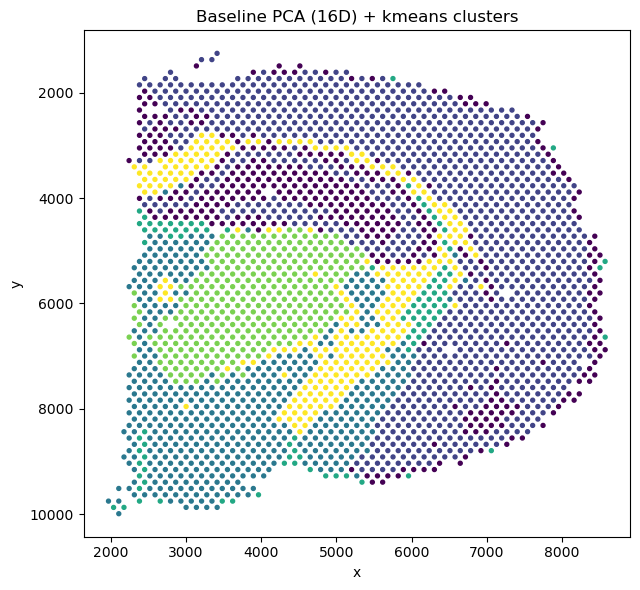

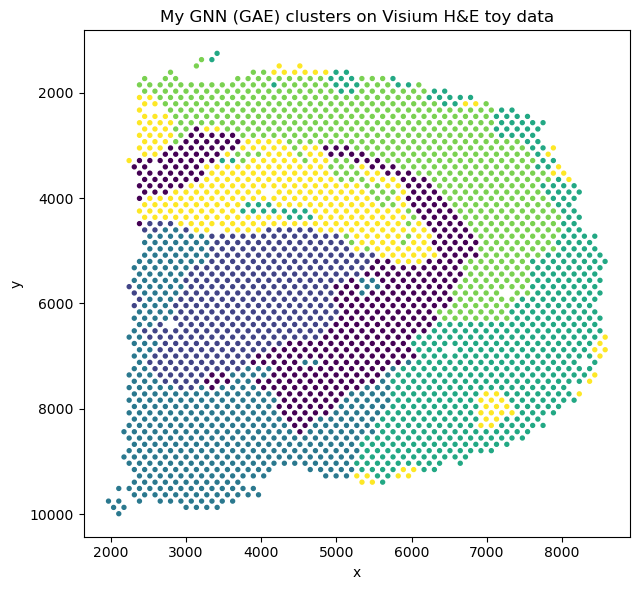

In [ ]:
# -----------------------------
# Visualize on tissue coordinates
# -----------------------------

# Plain PCA+kmeans (baseline)
from sklearn.decomposition import PCA
Z_pca = PCA(16, random_state=0).fit_transform(X)
labels_pca = KMeans(n_clusters=k, n_init=20, random_state=0).fit_predict(Z_pca)

plt.figure(figsize=(6.5, 6))
plt.scatter(xy[:, 0], xy[:, 1], c=labels_pca, s=8)
plt.gca().invert_yaxis()
plt.title("Baseline PCA (16D) + kmeans clusters")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.show()

# My minimal GNN output
xy = coords
plt.figure(figsize=(6.5, 6))
plt.scatter(xy[:, 0], xy[:, 1], c=labels, s=8)
plt.gca().invert_yaxis()     # Visium coords often have inverted y in image space
plt.title("My GNN (GAE) clusters on Visium H&E toy data")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.show()




# Results

- The GNN-based embeddings produced spatially contiguous clusters, aligning well with visible tissue domains on the H&E image.

- Compared to the PCA baseline, the GNN clusters were more spatially coherent, reflecting how graph-based message passing smooths expression information across neighboring spots.

- The unsupervised Graph Autoencoder successfully learned representations that integrate both gene expression similarity and spatial proximity — without using any labeled data.